# Lung Cancer Survival Detection

## Objective 
Build a system that can predict whether a patient survives based on patient details and medical information.

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

#Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

## 2. Load Dataset

In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Users\THRISHA\OneDrive\ドキュメント\dataset_med.csv")
df

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889995,889996,40.0,Male,Malta,2022-07-01,Stage IV,No,Passive Smoker,44.8,243,1,1,1,0,Radiation,2023-02-23,0
889996,889997,62.0,Female,Cyprus,2015-09-27,Stage II,Yes,Former Smoker,21.6,240,0,0,0,0,Surgery,2017-06-19,0
889997,889998,48.0,Female,Estonia,2016-03-27,Stage III,Yes,Never Smoked,38.6,242,1,0,0,0,Combined,2017-01-23,1
889998,889999,67.0,Female,Slovakia,2015-12-22,Stage IV,Yes,Former Smoker,18.6,194,1,1,0,0,Chemotherapy,2017-12-12,0


## 3. Dataset Overview

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (890000, 17)


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  890000 non-null  int64  
 1   age                 890000 non-null  float64
 2   gender              890000 non-null  object 
 3   country             890000 non-null  object 
 4   diagnosis_date      890000 non-null  object 
 5   cancer_stage        890000 non-null  object 
 6   family_history      890000 non-null  object 
 7   smoking_status      890000 non-null  object 
 8   bmi                 890000 non-null  float64
 9   cholesterol_level   890000 non-null  int64  
 10  hypertension        890000 non-null  int64  
 11  asthma              890000 non-null  int64  
 12  cirrhosis           890000 non-null  int64  
 13  other_cancer        890000 non-null  int64  
 14  treatment_type      890000 non-null  object 
 15  end_treatment_date  890000 non-nul

In [5]:
# Statistical summary
df.describe()

,id,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,survived
count,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000
mean,445000.500000,55.007008,30.494172,233.633916,0.750024,0.469740,0.225956,0.088157,0.220229
std,256921.014128,9.994485,8.368539,43.432278,0.432999,0.499084,0.418211,0.283524,0.414401
min,1.000000,4.000000,16.000000,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,222500.750000,48.000000,23.300000,196.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,445000.500000,55.000000,30.500000,242.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,667500.250000,62.000000,37.700000,271.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,890000.000000,104.000000,45.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id                    0
age                   0
gender                0
country               0
diagnosis_date        0
cancer_stage          0
family_history        0
smoking_status        0
bmi                   0
cholesterol_level     0
hypertension          0
asthma                0
cirrhosis             0
other_cancer          0
treatment_type        0
end_treatment_date    0
survived              0
dtype: int64


In [7]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 4. Data Preprocessing

In [8]:
# Remove columns that do not contribute directly to prediction
# 'id' is a unique identifier and does not contain predictive information.
# 'diagnosis_date' and 'end_treatment_date' were initially used to create treatment duration as a new feature. However, incorporating date-related-
# -information did not lead to any significant improvement in model performance.
# Therefore, these date columns were removed before model training.
df.drop(['id', 'diagnosis_date', 'end_treatment_date'],axis=1,inplace=True)

# Verify updated dataset shape
print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (890000, 14)


In [9]:
# Categorical columns
categorical_columns = ['gender','country','cancer_stage','family_history','smoking_status','treatment_type']

# Displaying unique values and their LabelEncoder mappings
for col in categorical_columns:
    le = LabelEncoder()
    le.fit(df[col])

    print(f"\n{col}")
    print("Unique Values:", df[col].unique())
    print("Encoding Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


gender
Unique Values: ['Male' 'Female']
Encoding Mapping: {'Female': 0, 'Male': 1}

country
Unique Values: ['Sweden' 'Netherlands' 'Hungary' 'Belgium' 'Luxembourg' 'Italy' 'Croatia'
 'Denmark' 'Malta' 'Germany' 'Poland' 'Ireland' 'Romania' 'Spain' 'Greece'
 'Estonia' 'Cyprus' 'France' 'Slovenia' 'Latvia' 'Portugal' 'Austria'
 'Czech Republic' 'Finland' 'Lithuania' 'Slovakia' 'Bulgaria']
Encoding Mapping: {'Austria': 0, 'Belgium': 1, 'Bulgaria': 2, 'Croatia': 3, 'Cyprus': 4, 'Czech Republic': 5, 'Denmark': 6, 'Estonia': 7, 'Finland': 8, 'France': 9, 'Germany': 10, 'Greece': 11, 'Hungary': 12, 'Ireland': 13, 'Italy': 14, 'Latvia': 15, 'Lithuania': 16, 'Luxembourg': 17, 'Malta': 18, 'Netherlands': 19, 'Poland': 20, 'Portugal': 21, 'Romania': 22, 'Slovakia': 23, 'Slovenia': 24, 'Spain': 25, 'Sweden': 26}

cancer_stage
Unique Values: ['Stage I' 'Stage III' 'Stage IV' 'Stage II']
Encoding Mapping: {'Stage I': 0, 'Stage II': 1, 'Stage III': 2, 'Stage IV': 3}

family_history
Unique Values: ['

In [10]:
# Initializing Label Encoder
le = LabelEncoder()

# Label Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
    
df.head()

,age,gender,country,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,survived
0,64.0,1,26,0,1,3,29.4,199,0,0,1,0,0,0
1,50.0,0,19,2,1,3,41.2,280,1,1,0,0,3,1
2,65.0,0,12,2,1,1,44.0,268,1,1,0,0,1,0
3,51.0,0,1,0,0,3,43.0,241,1,1,0,0,0,0
4,37.0,1,17,0,0,3,19.7,178,0,0,0,0,1,0


In [11]:
# Verifying updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   age                890000 non-null  float64
 1   gender             890000 non-null  int32  
 2   country            890000 non-null  int32  
 3   cancer_stage       890000 non-null  int32  
 4   family_history     890000 non-null  int32  
 5   smoking_status     890000 non-null  int32  
 6   bmi                890000 non-null  float64
 7   cholesterol_level  890000 non-null  int64  
 8   hypertension       890000 non-null  int64  
 9   asthma             890000 non-null  int64  
 10  cirrhosis          890000 non-null  int64  
 11  other_cancer       890000 non-null  int64  
 12  treatment_type     890000 non-null  int32  
 13  survived           890000 non-null  int64  
dtypes: float64(2), int32(6), int64(6)
memory usage: 74.7 MB


## 5. Exploratory Data Analysis (EDA)

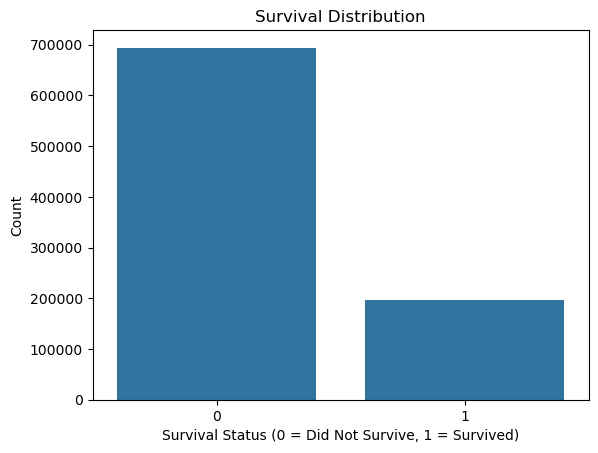

In [12]:
#Distribution of Target variable
sns.countplot(x='survived', data=df)
plt.title('Survival Distribution')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Count')
plt.show()

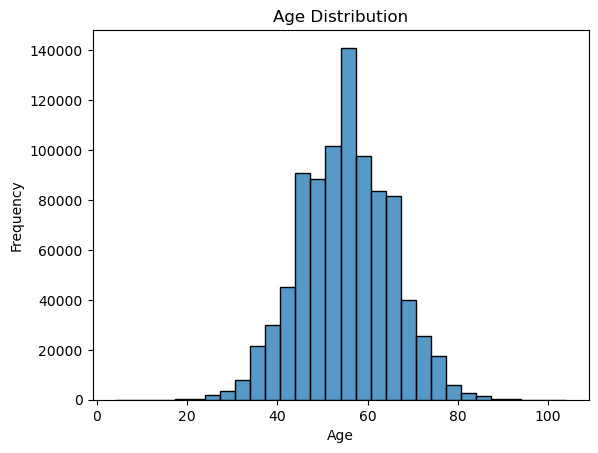

In [13]:
# Visualizing the distribution of patient age
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

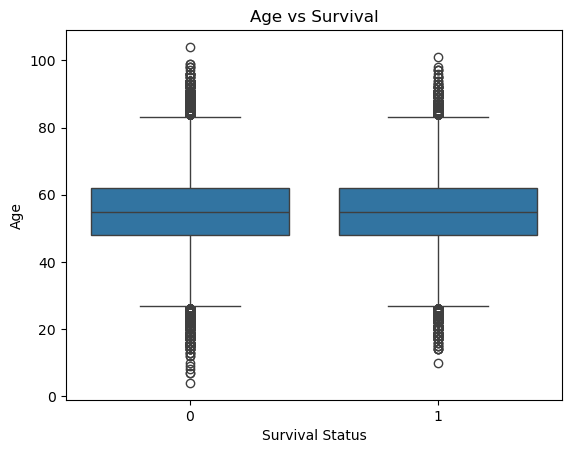

In [14]:
# Analyzing the relationship between age and survival
sns.boxplot(x='survived', y='age', data=df)
plt.title('Age vs Survival')
plt.xlabel('Survival Status')
plt.ylabel('Age')
plt.show()

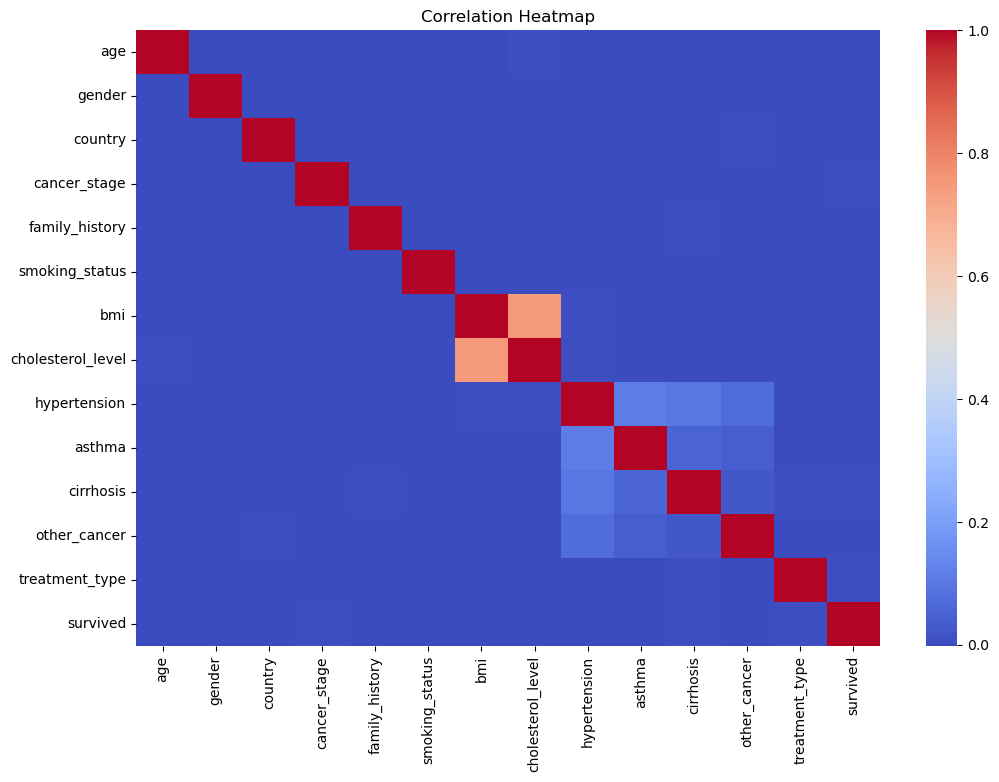

In [15]:
# Visualizing correlations between numerical features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

EDA showed that several features had similar distributions across both survival classes, indicating that individual features alone may not strongly influence survival outcomes. Therefore, machine learning models were used to identify patterns and relationships among multiple features simultaneously.

## 6. Feature and Target Separation

In [16]:
# Separate input features and target variable
X = df.drop('survived', axis=1)
y = df['survived']
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (890000, 13)
Target Shape : (890000,)


## 7. Train-Test Split

In [17]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (712000, 13)
X_test Shape : (178000, 13)
y_train Shape: (712000,)
y_test Shape : (178000,)


## 8. Feature Scaling

In [18]:
# Initializing StandardScaler
scaler = StandardScaler()

# Scale training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape :", X_test_scaled.shape)

X_train_scaled Shape: (712000, 13)
X_test_scaled Shape : (178000, 13)


## 9. Model Training and Evaluation

### 9.1 Logistic Regression

In [19]:
# Initializing Logistic Regression model
lr = LogisticRegression(random_state=42)

# Training the model
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [20]:
# Predictions on test data
y_pred_lr = lr.predict(X_test_scaled)

In [21]:
# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.7797696629213483
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


In [22]:
# Classification report
print(classification_report(y_test, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88    138799
           1       0.00      0.00      0.00     39201

    accuracy                           0.78    178000
   macro avg       0.39      0.50      0.44    178000
weighted avg       0.61      0.78      0.68    178000



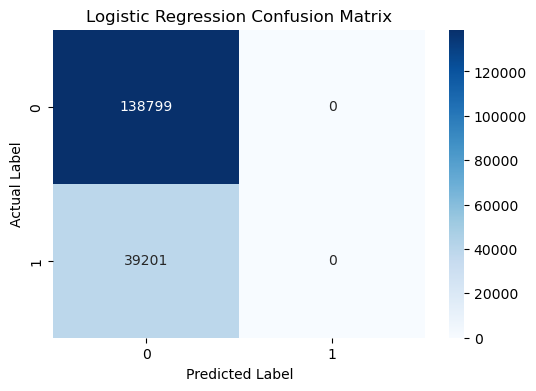

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Visualizing confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.2 Decision Tree Classifier

In [24]:
# Initializing Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Training the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [25]:
# Predictions on test data
dt_pred = dt_model.predict(X_test)

In [26]:
# Evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.6428876404494382
Precision: 0.22440900350639068
Recall   : 0.2530547690109946
F1 Score : 0.23787257511450016


In [27]:
# Classification report
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.78      0.75      0.77    138799
           1       0.22      0.25      0.24     39201

    accuracy                           0.64    178000
   macro avg       0.50      0.50      0.50    178000
weighted avg       0.66      0.64      0.65    178000



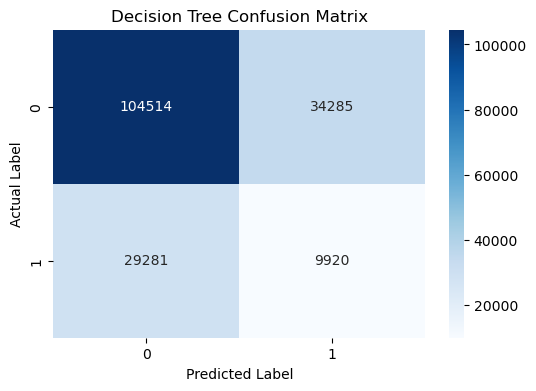

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.3 Random Forest Classifier

In [29]:
# Initializing Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

# Training the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
# Predictions on test data
rf_pred = rf_model.predict(X_test)

In [31]:
# Evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.7784213483146067
Precision: 0.22727272727272727
Recall   : 0.0025509553327721234
F1 Score : 0.0050452814005701166


In [32]:
# Classification report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88    138799
           1       0.23      0.00      0.01     39201

    accuracy                           0.78    178000
   macro avg       0.50      0.50      0.44    178000
weighted avg       0.66      0.78      0.68    178000



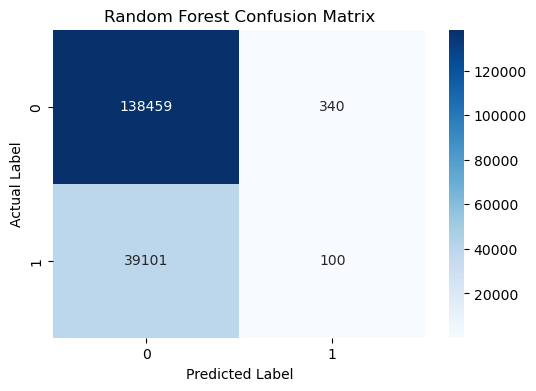

In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Random Forest with Class Weights

In [34]:
# Training Random Forest model with balanced class weights
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
print("Random Forest model with class weights trained successfully.")

Random Forest model with class weights trained successfully.


In [35]:
# Predictions using Random Forest model with balanced class weights
y_pred_balanced = rf_balanced.predict(X_test)
print("Predictions completed.")

Predictions completed.


In [36]:
# Evaluation metrics
rf_weighted_accuracy = accuracy_score(y_test, y_pred_balanced)
rf_weighted_precision = precision_score(y_test, y_pred_balanced)
rf_weighted_recall = recall_score(y_test, y_pred_balanced)
rf_weighted_f1 = f1_score(y_test, y_pred_balanced)

print("Accuracy :", rf_weighted_accuracy)
print("Precision:", rf_weighted_precision)
print("Recall   :", rf_weighted_recall)
print("F1 Score :", rf_weighted_f1)

Accuracy : 0.778685393258427
Precision: 0.2219020172910663
Recall   : 0.0019642356062345347
F1 Score : 0.0038940022251441287


In [37]:
#Classification Report
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88    138799
           1       0.22      0.00      0.00     39201

    accuracy                           0.78    178000
   macro avg       0.50      0.50      0.44    178000
weighted avg       0.66      0.78      0.68    178000



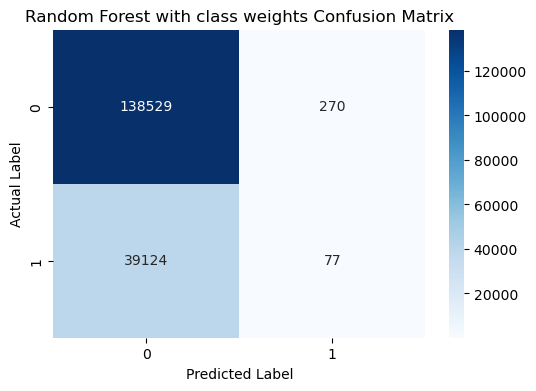

In [38]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest with class weights Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 10. Model Comparison

In [39]:
# Create model comparison table
comparison_df = pd.DataFrame({'Model': ['Logistic Regression','Decision Tree','Random Forest','Random Forest with Class Weights'],
    'Accuracy': [lr_accuracy,dt_accuracy,rf_accuracy,rf_weighted_accuracy],
    'Precision': [lr_precision,dt_precision,rf_precision,rf_weighted_precision],
    'Recall': [lr_recall,dt_recall,rf_recall,rf_weighted_recall],
    'F1 Score': [lr_f1,dt_f1,rf_f1,rf_weighted_f1]})
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.779770,0.000000,0.000000,0.000000
1,Decision Tree,0.642888,0.224409,0.253055,0.237873
2,Random Forest,0.778421,0.227273,0.002551,0.005045
3,Random Forest with Class Weights,0.778685,0.221902,0.001964,0.003894


## 11. Final Model Selection

Logistic Regression, Decision Tree, Random Forest, and Random Forest with Class Weights models were trained and evaluated for lung cancer survival prediction. Although Logistic Regression and Random Forest achieved higher accuracy, they struggled to identify surviving patients and resulted in very low recall and F1-score values. Additionally, applying class weights to Random Forest did not result in any significant improvement in model performance. 

Among all the models, the Decision Tree classifier demonstrated the best overall performance by achieving the highest recall and F1-score while identifying the maximum number of surviving patients.

Since correctly predicting patient survival is important in medical applications, **the Decision Tree classifier was selected as the final model for lung cancer survival prediction.**

## 12. Prediction

In [40]:
# Sample patient data for prediction
sample_patient = pd.DataFrame({'age': [64],'gender': [1],'country': [26],'cancer_stage': [0],'family_history': [1],'smoking_status': [3],
                               'bmi': [29.4],'cholesterol_level': [199],'hypertension': [0],'asthma': [0],'cirrhosis': [1],'other_cancer': [0],
                               'treatment_type': [0]})

prediction = dt_model.predict(sample_patient)
if prediction[0] == 1:
    print("Predicted Class: Survived")
else:
    print("Predicted Class: Did Not Survive")

Predicted Class: Did Not Survive


In [41]:
sample_patient = pd.DataFrame({'age': [50],'gender': [0],'country': [19],'cancer_stage': [2],'family_history': [1],'smoking_status': [3],
                               'bmi': [41.2],'cholesterol_level': [280],'hypertension': [1],'asthma': [1],'cirrhosis': [0],'other_cancer': [0],
                               'treatment_type': [3]})

prediction = dt_model.predict(sample_patient)
if prediction[0] == 1:
    print("Predicted Class: Survived")
else:
    print("Predicted Class: Did Not Survive")

Predicted Class: Survived


In [42]:
import joblib
joblib.dump(dt_model, "lung_cancer_survival_model.pkl")

['lung_cancer_survival_model.pkl']